In [43]:
import numpy as np
from numpy.polynomial import Polynomial

import matplotlib.pyplot as plt
import warnings
# plt.style.use('dark_background')

from travel_time_estimator import charge_curve, travel_distance_over_time

In [44]:
# travel scenario
target_distance = 700.0  # km
travel_speed    = 110.0  # km/h
min_soc = 20.0
max_soc = 100.0

consumption_100 = 13.0  # kWh/100km
consumption_120 = 17.5  # kWh/100km

battery_kwh = 80.0
time_20_80  = 20.0  # minutes
time_80_100 = 30.0  # minutes

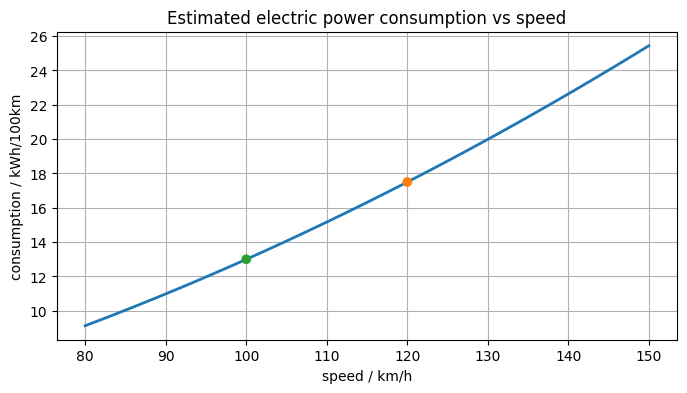

In [45]:
consumption_model = Polynomial.fit([0, 100, 120], [0, consumption_100, consumption_120], deg=2)

speed_range = np.linspace(80, 150, 101)

fig = plt.figure(figsize=(8, 4))
ax = fig.gca()
ax.plot(speed_range, consumption_model(speed_range), color="tab:blue", linewidth=2, label="estimated quadratic consumption")
ax.scatter([100, 120], [consumption_100, consumption_120], color=["tab:green", "tab:orange"], zorder=5)
ax.set_xlabel("speed / km/h")
ax.set_ylabel("consumption / kWh/100km")
ax.set_title("Estimated electric power consumption vs speed")
ax.grid(True)
# fig.savefig("consumption_curve.png", transparent=True, dpi=150)
plt.show()

if consumption_model.convert().coef[2] < 0:
    warnings.warn("Estimated consumption curve is not monotonically increasing. Check consumption values.")

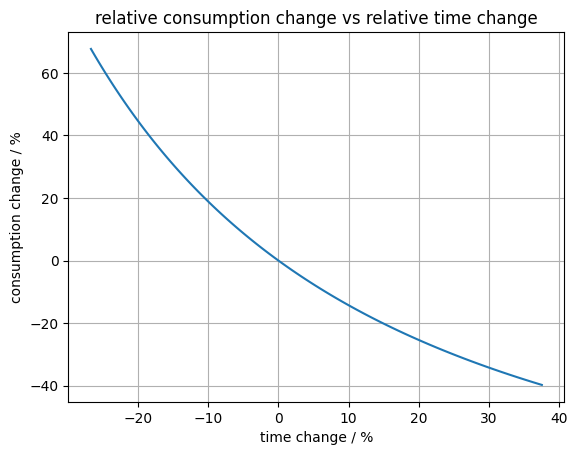

In [46]:
reference_speed = 110.0

time_ratio = (reference_speed / speed_range - 1) * 100
consumption_ratio = (consumption_model(speed_range) / consumption_model(reference_speed) - 1) * 100

plt.plot(time_ratio, consumption_ratio)
plt.xlabel("time change / %")
plt.ylabel("consumption change / %")
plt.title("relative consumption change vs relative time change")
plt.grid()

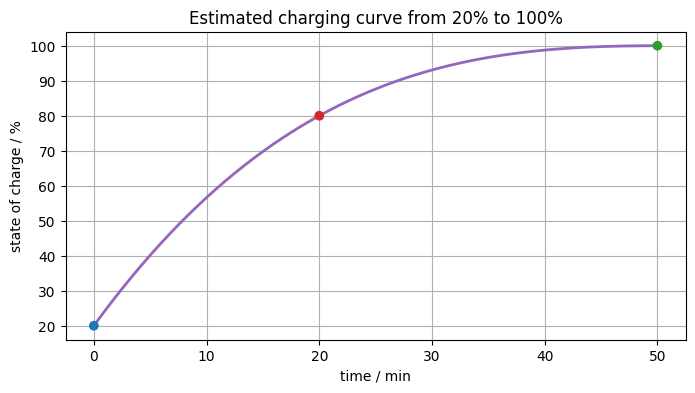

In [47]:
charge_model = charge_curve(time_20_80, time_80_100)

charge_time = np.linspace(0, time_20_80 + time_80_100, 301)

fig = plt.figure(figsize=(8, 4))
ax = fig.gca()
fig.patch.set_facecolor('none')
ax.set_facecolor('none')

ax.plot(charge_time, charge_model(charge_time), color="tab:purple", linewidth=2, label="estimated quadratic charge curve")
ax.scatter([0, time_20_80, time_20_80 + time_80_100], [20, 80, 100], color=["tab:blue", "tab:red", "tab:green"], zorder=5)
ax.set_xlabel("time / min")
ax.set_ylabel("state of charge / %")
ax.set_title("Estimated charging curve from 20% to 100%")
ax.grid(True)
# fig.savefig("charge_curve.png", transparent=True, dpi=150)
plt.show()


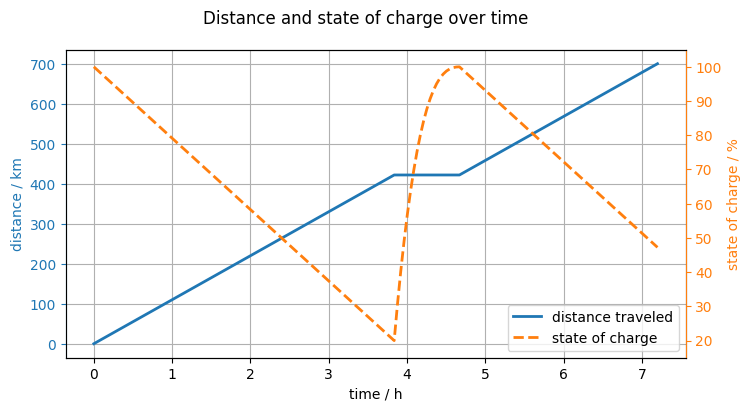

Estimated usable range: 422 km
Total trip time: 7.20 h


In [48]:
trip_time, trip_distance, trip_soc = travel_distance_over_time(
    target_distance, battery_kwh,
    consumption_model, charge_model,
    travel_speed,
    min_soc=min_soc,
    max_soc=max_soc,
)

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(trip_time, trip_distance, color='tab:blue', linewidth=2, label='distance traveled')
ax1.set_xlabel('time / h')
ax1.set_ylabel('distance / km', color='tab:blue')
ax1.tick_params(axis='y', colors='tab:blue')
ax1.spines['left'].set_color('tab:blue')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.set_facecolor('none')
ax2.plot(trip_time, trip_soc, color='tab:orange', linestyle='--', linewidth=2, label='state of charge')
ax2.set_ylabel('state of charge / %', color='tab:orange')
ax2.tick_params(axis='y', colors='tab:orange')
ax2.spines['right'].set_color('tab:orange')
ax2.set_ylim(min_soc - 5, max_soc + 5)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')
fig.suptitle('Distance and state of charge over time')
# fig.savefig("trip_distance_soc.png", transparent=True, dpi=150)
plt.show()

print(f"Estimated usable range: {battery_kwh * (max_soc - min_soc) / 100.0 / (consumption_model(travel_speed) / 100):.0f} km")
print(f"Total trip time: {trip_time[-1]:.2f} h")